# Theorem 10: Approximation Rates for Linear Continuous-Time RNNs

This notebook gives a concise numerical illustration of Theorem 10 in Li et al. (2022).

We compare two scalar target kernels:

1. an analytic target, substantially smoother than required;
2. a target whose transformed representation has deliberately limited smoothness.

For both targets, we use the constructive decay rates from the proof,

$$
\lambda_j=\frac{j\beta}{\alpha+1},
\qquad j=1,\ldots,m,
$$

and study the kernel error

$$
E(m)=\|\rho-\widehat\rho_m\|_{L^1(0,\infty)}.
$$

## 1. Theorem and experimental scope

For suitable linear, causal, regular, and time-homogeneous functionals, Theorem 10 gives a width-\(m\) linear RNN satisfying

$$
\sup_{t\in\mathbb R}
\sup_{\|x\|_{\mathcal X}\le 1}
\left|
H_t(x)-\widehat H_t(x)
\right|
\le
\frac{C(\alpha)\gamma d}
{\beta m^\alpha}.
$$

In the scalar case \(d=1\), the functional error is controlled by the kernel error:

$$
\sup_{t\in\mathbb R}
\sup_{\|x\|_{\mathcal X}\le 1}
\left|
H_t(x)-\widehat H_t(x)
\right|
\le
\left\|
\rho-\widehat\rho_m
\right\|_{L^1(0,\infty)}.
$$

The universal constant $C(\alpha)$ is not made explicit in the paper. We therefore compare:

- the observed $L^1$-kernel error;
- an empirical power-law fit;
- the reference envelope $\gamma/(\beta m^\alpha)$, using the illustrative choice $C(\alpha)=1$;
- the required normalized constant $C_{\mathrm{req}}(m)$.

The normalized constant is defined by

$$
C_{\mathrm{req}}(m)
=
E(m)\frac{\beta m^\alpha}{\gamma}.
$$

*Source: Li et al. (2022), Theorem 10 and its proof.*

## 2. Proof construction used numerically

The proof introduces

$$
s=e^{-\beta t/(\alpha+1)}
$$

and represents the kernel as

$$
\rho(t)
=
s\,q(s).
$$

Approximating $q$ by a polynomial

$$
Q_m(s)=\sum_{j=0}^{m-1}a_j s^j
$$

gives

$$
\widehat\rho_m(t)
=
s\,Q_m(s)
=
\sum_{j=1}^m
a_{j-1}
e^{-j\beta t/(\alpha+1)}.
$$

Thus the constructive RNN rates are

$$
\lambda_j=\frac{j\beta}{\alpha+1}.
$$

The experiment keeps these rates fixed and fits only the coefficients.

## 3. Import the experiment implementation

In [10]:
from pathlib import Path
import importlib.util

import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd

experiment_path = (
    PROJECT_ROOT
    / "experiments"
    / "04_theorem10_approximation_rates.py"
)

if not experiment_path.exists():
    raise FileNotFoundError(
        f"Could not find {experiment_path}. "
        "Start Jupyter from the repository root or notebooks/."
    )

spec = importlib.util.spec_from_file_location(
    "theorem10_experiment",
    experiment_path,
)
exp = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(exp)

print(f"Imported: {experiment_path}")

Imported: /Users/eduard/Desktop/Studium/Code/ct-rnn-memory-kernels/experiments/04_theorem10_approximation_rates.py


## 4. Target kernels

The analytic target is

$$
\rho_{\mathrm{analytic}}(t)
=
(1+t)e^{-2t}.
$$

It satisfies the assumptions for $\alpha=1$ and $\beta=1$, but is much smoother than required.

The limited-smoothness target is constructed from

$$
q_\delta(s)
=
s^2(1-s)^2
\left|s-\frac12\right|^{1+\delta},
\qquad
\delta=0.1,
$$

through

$$
\rho_{\mathrm{limited}}(t)
=
s\,q_\delta(s),
\qquad
s=e^{-t/2}.
$$

The factor $|s-\tfrac12|^{1+\delta}$ is continuously differentiable ($C^1$), but not twice continuously differentiable ($C^2$), for $0<\delta<1$.

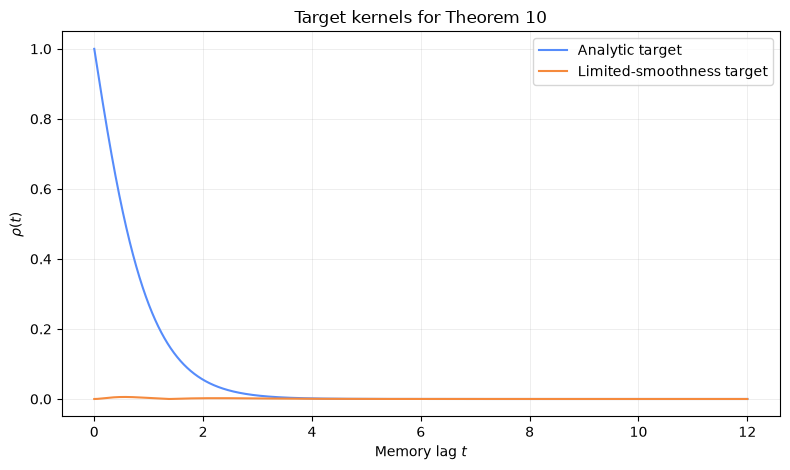

In [11]:
plot_grid = np.linspace(0.0, 12.0, 4000)

plt.figure(figsize=(8, 4.8))
plt.plot(
    plot_grid,
    exp.smooth_target_kernel(plot_grid),
    label="Analytic target",
)
plt.plot(
    plot_grid,
    exp.limited_smoothness_kernel(plot_grid),
    label="Limited-smoothness target",
)
plt.xlabel("Memory lag $t$")
plt.ylabel(r"$\rho(t)$")
plt.title("Target kernels for Theorem 10")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretation

The two target kernels represent different smoothness regimes covered by Theorem 10.

- The **analytic target** (blue) is smooth and decays exponentially. Since it is much smoother than required by the theorem, we expect its approximation error to decrease significantly faster than the theoretical rate $m^{-\alpha}$.

- The **limited-smoothness target** (orange) is constructed to satisfy the assumptions of Theorem 10 only marginally. The factor $|s-\tfrac12|^{1+\delta}$ introduces a point where the kernel is $C^1$ but not $C^2$, making it substantially less regular.

- Consequently, the second kernel provides a more faithful test of the approximation-rate prediction in Theorem 10, while the analytic kernel serves as a reference illustrating how additional smoothness can lead to much faster convergence.

## 5. Run both approximation experiments

In [12]:
smooth_gamma = exp.smooth_target_gamma()
limited_gamma = exp.limited_smoothness_gamma()

smooth_results = exp.run_target_experiment(
    target_name="Analytic target",
    target_function=exp.smooth_target_kernel,
    gamma=smooth_gamma,
)

limited_results = exp.run_target_experiment(
    target_name="Limited-smoothness target",
    target_function=exp.limited_smoothness_kernel,
    gamma=limited_gamma,
)

print(f"Analytic target gamma: {smooth_gamma:.6e}")
print(f"Limited-smoothness target gamma: {limited_gamma:.6e}")

Analytic target gamma: 1.213061e+00
Limited-smoothness target gamma: 3.819075e-02


## 6. Direct error comparison

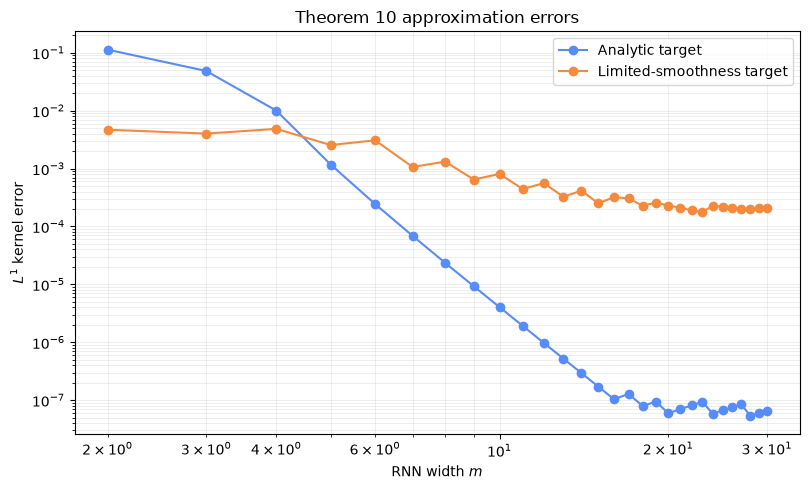

In [13]:
plt.figure(figsize=(8.2, 5.0))

for result in [smooth_results, limited_results]:
    plt.loglog(
        exp.WIDTHS,
        result["errors"],
        marker="o",
        label=result["name"],
    )

plt.xlabel("RNN width $m$")
plt.ylabel(r"$L^1$ kernel error")
plt.title("Theorem 10 approximation errors")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### Interpretation

The approximation error decreases for both target kernels as the RNN width $m$ increases, confirming the qualitative prediction of Theorem 10.

- The **analytic target** exhibits a much faster decay than the theoretical bound. Its high regularity allows the exponential basis to approximate the kernel extremely efficiently, with the error reaching approximately $10^{-7}$ already for $m\approx20$.

- The **limited-smoothness target** converges substantially more slowly. Since it only satisfies the smoothness assumptions of Theorem 10, it represents a much more demanding approximation problem and therefore provides the more informative validation of the theorem.

- The different values of
  $\gamma_{\mathrm{analytic}}\approx1.21$
  and
  $\gamma_{\mathrm{limited}}\approx3.82\times10^{-2}$
  only affect the overall scale of the theoretical error bound. They do **not** determine the convergence order with respect to $m$.

Overall, the experiment illustrates that Theorem 10 guarantees a worst-case approximation rate, while smoother kernels can converge considerably faster in practice.

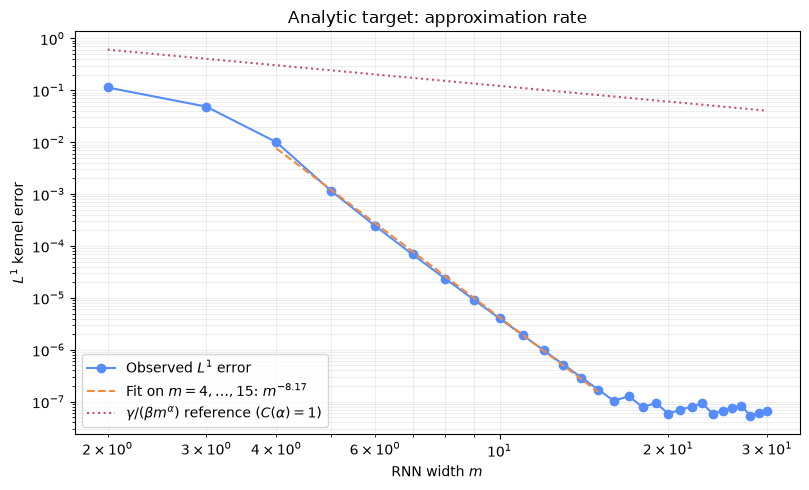

Empirical exponent: 8.174


In [14]:
def plot_rate(result):
    errors = np.asarray(result["errors"])
    fit_widths = np.asarray(result["fit_widths"])
    fitted_errors = np.asarray(result["fitted_errors"])
    exponent = float(result["empirical_exponent"])
    reference = np.asarray(result["unit_constant_envelope"])

    plt.figure(figsize=(8.2, 5.0))
    plt.loglog(
        exp.WIDTHS,
        errors,
        marker="o",
        label="Observed $L^1$ error",
    )
    plt.loglog(
        fit_widths,
        fitted_errors,
        linestyle="--",
        label=(
            f"Fit on $m={exp.FIT_MIN_WIDTH},\\ldots,"
            f"{exp.FIT_MAX_WIDTH}$: "
            f"$m^{{-{exponent:.2f}}}$"
        ),
    )
    plt.loglog(
        exp.WIDTHS,
        reference,
        linestyle=":",
        label=(
            r"$\gamma/(\beta m^\alpha)$ reference "
            r"($C(\alpha)=1$)"
        ),
    )
    plt.xlabel("RNN width $m$")
    plt.ylabel(r"$L^1$ kernel error")
    plt.title(f"{result['name']}: approximation rate")
    plt.legend()
    plt.grid(alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()

    print(
        f"Empirical exponent: {exponent:.3f}"
    )

plot_rate(smooth_results)

### Interpretation

The observed error decreases much faster than the approximation rate guaranteed by Theorem 10.

- The **blue curve** is the measured $L^1$ approximation error.

- The **orange dashed line** is a least-squares fit of the form
  $E(m)\approx Cm^{-p}$
  using the data for $m=4,\ldots,15$. The fitted exponent is
  $p\approx8.17$,
  indicating a convergence rate far faster than the theoretical rate.

- The **red dotted line** shows the reference bound
  $\gamma/(\beta m^\alpha)$
  with the illustrative choice $C(\alpha)=1$. It therefore has the theoretical slope $m^{-\alpha}$ (here $\alpha=1$).

The large gap between the observed error and the theoretical reference confirms that Theorem 10 provides a worst-case guarantee. For this analytic kernel, the additional smoothness leads to a substantially faster decay than predicted by the theorem.

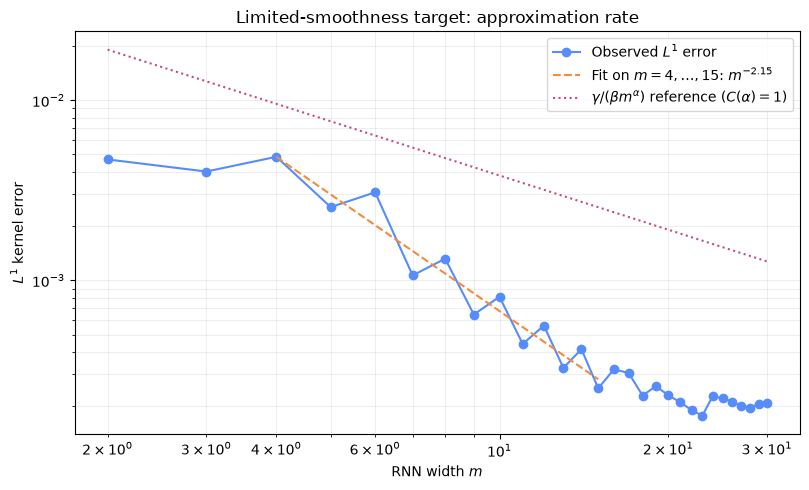

Empirical exponent: 2.151


In [6]:
plot_rate(limited_results)

### Interpretation

For the limited-smoothness kernel, the observed convergence is much closer to the setting covered by Theorem 10.

- The **blue curve** shows the measured $L^1$ approximation error.

- The **orange dashed line** is the empirical power-law fit
  $E(m)\approx Cm^{-p}$
  computed from the data for $m=4,\ldots,15$. The fitted exponent is
  $p\approx2.15$,
  indicating polynomial convergence.

- The **red dotted line** is the theoretical reference
  $\gamma/(\beta m^\alpha)$
  with the illustrative choice $C(\alpha)=1$, corresponding to the guaranteed rate $m^{-\alpha}$ (here $\alpha=1$).

Unlike the analytic kernel, this target is only marginally smoother than required by the theorem. Consequently, its convergence is much closer to the worst-case prediction, although the observed decay is still somewhat faster than the guaranteed rate. This demonstrates that Theorem 10 provides a conservative lower bound while remaining representative for kernels with limited smoothness.

## 8. Normalized error relative to the theorem

The quantity

$$
C_{\mathrm{req}}(m)
=
E(m)\frac{\beta m^\alpha}{\gamma}
$$

is the constant that would be required at a given width for the observed error to satisfy

$$
E(m)
\le
C_{\mathrm{req}}(m)
\frac{\gamma}{\beta m^\alpha}.
$$

It is target- and experiment-specific and must not be identified with the universal constant \(C(\alpha)\).

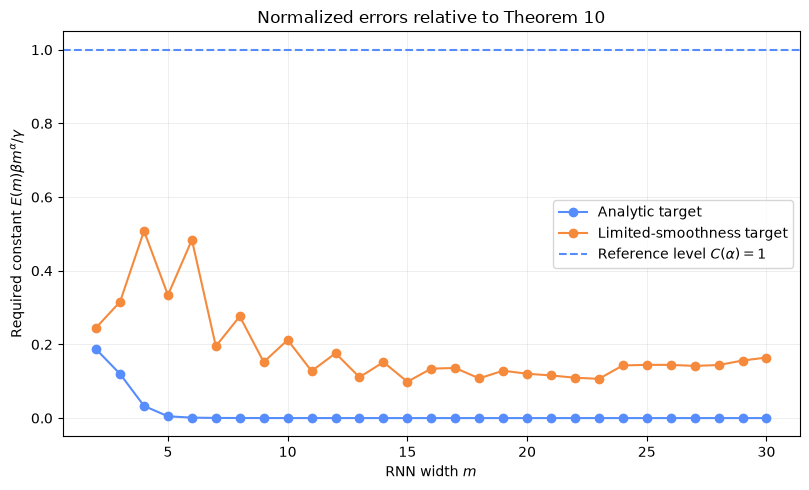

Analytic target: max required constant = 1.868e-01
Limited-smoothness target: max required constant = 5.082e-01


In [7]:
plt.figure(figsize=(8.2, 5.0))

for result in [smooth_results, limited_results]:
    plt.plot(
        exp.WIDTHS,
        result["required_constants"],
        marker="o",
        label=result["name"],
    )

plt.axhline(
    1.0,
    linestyle="--",
    label=r"Reference level $C(\alpha)=1$",
)
plt.xlabel("RNN width $m$")
plt.ylabel(
    r"Required constant "
    r"$E(m)\beta m^\alpha/\gamma$"
)
plt.title("Normalized errors relative to Theorem 10")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for result in [smooth_results, limited_results]:
    print(
        f"{result['name']}: "
        f"max required constant = "
        f"{np.max(result['required_constants']):.3e}"
    )

### Interpretation

This plot shows the empirical constant

$$
C_{\mathrm{req}}(m)
=
E(m)\frac{\beta m^\alpha}{\gamma},
$$

that would be required for the observed approximation error to satisfy the bound in Theorem 10.

- For the **analytic target** (blue), the required constant rapidly decreases and remains well below $1$. The maximum value is only $0.187$, showing that the theorem is highly conservative for this very smooth kernel.

- For the **limited-smoothness target** (orange), the required constant is larger but still remains below $1$ for every tested width. The maximum value is $0.508$, indicating that the approximation behaves much closer to the theoretical worst case.

- Since both curves stay below the reference level $C(\alpha)=1$, the theoretical rate with this illustrative constant is sufficient to explain all observed errors in these experiments.

Overall, the experiment confirms that Theorem 10 provides a conservative upper bound: very smooth kernels require only a small fraction of the theoretical constant, whereas kernels with limited smoothness come substantially closer to the worst-case behavior predicted by the theorem.

## 9. Numerical conditioning

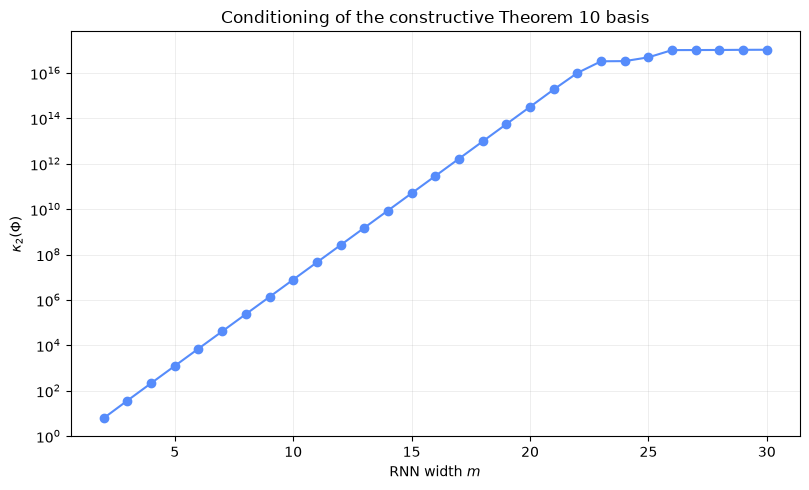

In [15]:
condition_numbers = np.asarray(
    smooth_results["condition_numbers"]
)

plt.figure(figsize=(8.2, 5.0))
plt.semilogy(
    exp.WIDTHS,
    condition_numbers,
    marker="o",
)
plt.xlabel("RNN width $m$")
plt.ylabel(r"$\kappa_2(\Phi)$")
plt.title(
    "Conditioning of the constructive Theorem 10 basis"
)
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

### Interpretation

This plot shows the condition number $\kappa_2(\Phi)$ of the exponential basis matrix used in the constructive approximation of Theorem 10.

- The condition number increases rapidly with the RNN width, reaching values above $10^{16}$. This indicates that the basis becomes increasingly ill-conditioned as more exponential basis functions are added.

- A large condition number implies that the least-squares problem becomes highly sensitive to numerical round-off errors. Small perturbations in the data may lead to large changes in the fitted coefficients.

- Despite this severe ill-conditioning, the approximation errors shown in the previous experiments continue to decrease until they reach the numerical accuracy limit. Thus, in this experiment the approximation quality is not limited by the theorem itself but eventually by floating-point precision.

Overall, the plot illustrates that the constructive basis of Theorem 10 becomes numerically unstable for large widths, even though accurate approximations can still be obtained up to the point where numerical precision becomes the dominant limitation.

## 10. Summary table

In [16]:
for result in [smooth_results, limited_results]:
    best_index = int(
        np.argmin(result["errors"])
    )

    print(result["name"])
    print(
        f"  gamma: {float(result['gamma']):.6e}"
    )
    print(
        f"  empirical exponent: "
        f"{float(result['empirical_exponent']):.3f}"
    )
    print(
        f"  maximum required constant: "
        f"{np.max(result['required_constants']):.3e}"
    )
    print(
        f"  smallest observed error: "
        f"{result['errors'][best_index]:.3e} "
        f"at m={exp.WIDTHS[best_index]}"
    )
    print()

Analytic target
  gamma: 1.213061e+00
  empirical exponent: 8.174
  maximum required constant: 1.868e-01
  smallest observed error: 5.376e-08 at m=28

Limited-smoothness target
  gamma: 3.819075e-02
  empirical exponent: 2.151
  maximum required constant: 5.082e-01
  smallest observed error: 1.770e-04 at m=23



### Interpretation

The summary highlights the qualitative difference between the two target kernels.

- The **analytic target** exhibits an empirical convergence rate of approximately $m^{-8.17}$, far exceeding the theoretical guarantee of $m^{-\alpha}$ with $\alpha=1$. Its maximum required constant is only $0.187$, confirming that Theorem 10 is highly conservative for very smooth kernels.

- The **limited-smoothness target** converges much more slowly, with an empirical rate of approximately $m^{-2.15}$. This behavior is considerably closer to the theoretical prediction, and the larger required constant ($0.508$) indicates that this target lies much nearer to the worst-case regime addressed by the theorem.

- Both targets require normalized constants well below the illustrative reference value $C(\alpha)=1$, showing that the theoretical bound comfortably explains the observed approximation errors throughout the experiments.

Overall, the experiments confirm that additional smoothness can substantially accelerate convergence beyond the guaranteed rate, whereas kernels with limited smoothness behave much closer to the approximation rate predicted by Theorem 10.

## 11. Limitations

- The universal constant $C(\alpha)$ is unknown.
- The coefficients are obtained by discrete least squares, not by the exact Jackson construction.
- The empirical exponents are fitted over a finite pre-plateau range and are not proved asymptotic rates.
- The limited-smoothness target is designed for illustration and is not claimed to attain the exact worst-case rate.
- Large widths are affected by severe ill-conditioning of the exponential basis.

## 12. Reference

Li, Zhong, Jiequn Han, Weinan E, and Qianxiao Li. 2022.  
“Approximation and Optimization Theory for Linear Continuous-Time Recurrent Neural Networks.”  
*Journal of Machine Learning Research* 23 (42): 1–85.

Relevant locations: Theorem 10, equation (27), and the proof of Theorem 10.

```bibtex
@article{li2022approximation,
  author  = {Li, Zhong and Han, Jiequn and E, Weinan and Li, Qianxiao},
  title   = {Approximation and Optimization Theory for Linear Continuous-Time Recurrent Neural Networks},
  journal = {Journal of Machine Learning Research},
  year    = {2022},
  volume  = {23},
  number  = {42},
  pages   = {1--85},
  url     = {https://jmlr.org/papers/v23/21-0368.html}
}
```